## Setup

In [1]:
# notebooks/01_data_cleaning.ipynb
#
# Cleaning pipeline for the Steam 2024 — Top 1,500 Games by Revenue dataset.
#
# NOTE ON OUTLIERS: this dataset is a "top N by revenue" ranking, so it is
# heavily right-skewed by construction — a handful of hits (Black Myth:
# Wukong, HELLDIVERS 2, Palworld, ...) legitimately dwarf the rest. A
# standard IQR-based capping step would misidentify those exact rows as
# "outliers" and clip them all down to the same value, destroying the
# signal the dataset exists to show. So this version does NOT blanket-cap
# numeric columns. Instead it relies on the domain checks already enforced
# in src/data_loader.py's validate_schema() (no negative price/revenue,
# reviewScore in [0, 100], no duplicate steamId) and only logs anything
# that looks like a genuine data-entry problem, without altering values.

import sys
from pathlib import Path
sys.path.append(str(Path.cwd().parent))

import pandas as pd
import numpy as np
from src.data_loader import DataLoader


## Load & Validate Raw Data

In [2]:
PROJECT_ROOT = Path.cwd().parent
reports_dir = PROJECT_ROOT / 'reports'
reports_dir.mkdir(parents=True, exist_ok=True)

# Load raw data
loader = DataLoader()
df = loader.load_raw_data()          # data/raw/Steam_2024_bestRevenue_1500.csv
loader.validate_schema()             # raises if anything is structurally wrong


INFO | Loaded Steam_2024_bestRevenue_1500.csv -> 1500 rows x 11 columns
INFO | Schema validation passed.


True

## Cleaning Pipeline

Defines `clean_data()`: fills missing values, drops duplicates, runs sanity checks, tidies dtypes, and adds a derived `revenue_per_copy` column.

In [3]:
def clean_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Cleaning pipeline for the Steam 2024 revenue dataset.
    Returns cleaned DataFrame; writes a log of every change made.
    """
    cleaned_df = df.copy()
    cleaning_log = []

    # 1. Handle Missing Values
    for col in cleaned_df.columns:
        missing = cleaned_df[col].isnull().sum()
        if missing == 0:
            continue
        if pd.api.types.is_numeric_dtype(cleaned_df[col]):
            median = cleaned_df[col].median()
            cleaned_df[col] = cleaned_df[col].fillna(median)
            cleaning_log.append(
                f"Filled {missing} missing values in '{col}' with median ({median})"
            )
        else:
            mode = cleaned_df[col].mode()
            if len(mode) > 0:
                cleaned_df[col] = cleaned_df[col].fillna(mode[0])
                cleaning_log.append(
                    f"Filled {missing} missing values in '{col}' with mode ('{mode[0]}')"
                )

    # 2. Remove Duplicates
    duplicates = cleaned_df.duplicated().sum()
    if duplicates > 0:
        cleaned_df = cleaned_df.drop_duplicates()
        cleaning_log.append(f"Removed {duplicates} duplicate rows")


    # 3. Collapse rare categories in `publisherClass`
    # Steam's publisherClass taxonomy has 4 levels (AAA/AA/Indie/Hobbyist),
    # but this dataset contains only a single 'Hobbyist' row -- too few to
    # support any group-level statistic (mean, box plot, ANOVA cell, etc.).
    # Hobbyist and Indie sit next to each other on Steam's scale (small,
    # self-published titles), so fold the lone Hobbyist row into Indie
    # rather than dropping it or leaving a single-point group in every
    # groupby/plot downstream.
    if 'publisherClass' in cleaned_df.columns:
        n_hobbyist = (cleaned_df['publisherClass'] == 'Hobbyist').sum()
        if n_hobbyist > 0:
            cleaned_df['publisherClass'] = (
                cleaned_df['publisherClass']
                .astype(str)
                .replace({'Hobbyist': 'Indie'})
                .astype('category')
            )
            cleaning_log.append(
                f"Collapsed {n_hobbyist} 'Hobbyist' row(s) in 'publisherClass' into "
                "'Indie' (too few Hobbyist rows to support as its own group)"
            )
    # 4. Sanity checks (log-only, no silent modification)
    # These mirror validate_schema()'s checks; since load already validated
    # the raw file, this section should normally find nothing — it exists
    # as a safety net in case clean_data() is ever called on other data.
    if (cleaned_df['price'] < 0).any():
        n = (cleaned_df['price'] < 0).sum()
        cleaning_log.append(f"WARNING: {n} row(s) have negative price (left unmodified)")

    if (cleaned_df['revenue'] < 0).any():
        n = (cleaned_df['revenue'] < 0).sum()
        cleaning_log.append(f"WARNING: {n} row(s) have negative revenue (left unmodified)")

    if not cleaned_df['reviewScore'].dropna().between(0, 100).all():
        cleaning_log.append("WARNING: some reviewScore values fall outside 0-100 (left unmodified)")

    # 5. Fix Data Types (light touch — only convert genuinely low-cardinality
    #    text columns to category; do NOT touch numeric columns' scale/values)
    low_cardinality_text_cols = [
        col for col in cleaned_df.select_dtypes(include=['object', 'string']).columns
        if cleaned_df[col].nunique() < 10
    ]
    for col in low_cardinality_text_cols:
        cleaned_df[col] = cleaned_df[col].astype('category')
        cleaning_log.append(f"Converted '{col}' to categorical")

    # 6. Derived columns (optional — comment out if you don't want these)
    if 'revenue' in cleaned_df.columns and 'copiesSold' in cleaned_df.columns:
        cleaned_df['revenue_per_copy'] = cleaned_df['revenue'] / cleaned_df['copiesSold']
        cleaning_log.append("Added 'revenue_per_copy' (revenue / copiesSold)")

    # NOTE: deliberately NOT capping/clipping copiesSold, revenue, price, or
    # avgPlaytime — see the notebook intro above for why blanket IQR capping
    # is the wrong tool for a "top N by revenue" dataset.

    # Log cleaning actions
    with open(reports_dir / 'cleaning_log.txt', 'w', encoding='utf-8') as f:
        f.write("DATA CLEANING LOG\n")
        f.write("=" * 50 + "\n\n")
        for action in cleaning_log:
            f.write(f"- {action}\n")
        f.write(f"\nFinal shape: {cleaned_df.shape}\n")

    return cleaned_df


## Run Cleaning & Save Output

In [4]:
# Clean the data
df_clean = clean_data(df)

# Save cleaned data (base version; the robust-preparation section at the bottom
# overwrites this same file with the enriched version, so only one CSV is kept)
loader.save_processed(df_clean, "cleaned_data.csv")

# Show summary of changes
print("\nData cleaning complete!")
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_clean.shape}")
print("Check reports/cleaning_log.txt for details")


INFO | Saved processed data -> F:\Projects\statistics-standards-updated new\data\processed\cleaned_data.csv



Data cleaning complete!
Original shape: (1500, 11)
Cleaned shape: (1500, 12)
Check reports/cleaning_log.txt for details


---

## Extending the cleaning pipeline: robust data preparation

The steps above produce a base `cleaned_data.csv`. The section below audits it further and builds the log-scale / indicator features (disguised missing review scores, free-to-play flag, left-truncation) used by the analysis in notebooks `02`, `04`–`06`, and saves the result back to `data/processed/cleaned_data.csv`, overwriting the base version. `cleaned_data.csv` is the only processed file; there is no separate `robust_data.csv`.

## Robust Data Preparation

**Week 3 — re-analysis with methods suited to heavy-tailed commercial data**

Week 2 applied mean-based, parametric procedures to variables with skewness up to 22.9 and excess kurtosis near 600. This notebook (i) audits the data for problems those procedures ignored and (ii) builds the log-scale and indicator features used in notebooks 02, 04–06.

**Findings this notebook establishes**

1. `reviewScore == 0` is a disguised missing value, and it is *not* missing at random.
2. `price == 0` marks free-to-play games; their revenue is not `price × copies`.
3. The sample is **left-truncated** on revenue (top-1,500 selection), which matters for distribution fitting and regression.
4. A log10 transform removes most — but not all — of the skew.

In [5]:
import sys, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sys.path.append(str(Path.cwd().parent))  # project root: import via the src package so src/statistics.py cannot shadow the stdlib module
from src import statistics as rs

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "axes.titleweight": "bold", "axes.titlesize": 12})
pd.options.display.float_format = "{:,.4g}".format
pd.options.display.width = 140

df = rs.load_robust()
CLS = rs.CLASS_ORDER
PAL = rs.CLASS_COLORS
print(f"n = {len(df):,}  |  columns = {df.shape[1]}")

n = 1,500  |  columns = 20


## 1. Disguised missing values and special codes

In [6]:
audit = pd.DataFrame({
    "check": ["reviewScore == 0", "price == 0 (free-to-play)", "avgPlaytime == 0", "revenue <= 0", "copiesSold <= 0"],
    "n": [(df.reviewScore == 0).sum(), (df.price == 0).sum(), (df.avgPlaytime == 0).sum(),
          (df.revenue <= 0).sum(), (df.copiesSold <= 0).sum()],
})
audit["% of rows"] = 100 * audit["n"] / len(df)
audit

,check,n,% of rows
0,reviewScore == 0,99,6.6
1,price == 0 (free-to-play),85,5.667
2,avgPlaytime == 0,1,0.06667
3,revenue <= 0,0,0
4,copiesSold <= 0,0,0


### 1.1 Is `reviewScore == 0` missing at random?

If the 99 zero-score games were a random subset, their revenue would look like everyone else's. They do not: a Mann–Whitney U test compares revenue between games *with* and *without* a recorded score.

In [7]:
grp = df.groupby("has_review")[["revenue", "copiesSold", "price"]].median().rename(index={True: "has score", False: "score == 0"})
print(grp.to_string())

u = stats.mannwhitneyu(df.loc[~df.has_review, "revenue"], df.loc[df.has_review, "revenue"])
delta = rs.cliffs_delta(df.loc[~df.has_review, "revenue"], df.loc[df.has_review, "revenue"])
print(f"\nMann-Whitney U (revenue, no-score vs scored): p = {u.pvalue:.2e}, Cliff's delta = {delta:+.3f} ({rs.cliffs_label(delta)})")

ct = pd.crosstab(df.publisherClass, df.has_review, normalize="index").mul(100).round(1)
ct.columns = ["% score == 0", "% has score"]
print("\nShare of games with no score, by publisher class:")
print(ct.to_string())

             revenue  copiesSold  price
has_review                             
score == 0 2.676e+05   3.039e+04  16.99
has score  1.013e+05   1.102e+04  14.99

Mann-Whitney U (revenue, no-score vs scored): p = 4.15e-08, Cliff's delta = +0.329 (small)

Share of games with no score, by publisher class:
                % score == 0  % has score
publisherClass                           
Indie                    6.5         93.5
AA                       7.5         92.5
AAA                      5.8         94.2


**Interpretation.** Games without a score earn *more* revenue at the median, so listwise deletion or treating 0 as a real rating both bias downstream results. Decision: recode to `NaN` in `reviewScore_clean` and (a) run review-based analyses on the 1,401 scored games, (b) keep a `has_review` indicator so regressions can include the unscored games as a sensitivity check.

## 2. Free-to-play games and the price × copies identity

For paid games revenue is tied to `price × copiesSold` (median ratio ≈ 0.81, so revenue is systematically below list price × units, consistent with discounts, regional pricing, refunds or platform fees). For free games the identity cannot hold at all, so `price`-based summaries silently mix two different business models.

In [8]:
paid = df[~df.is_free].copy()
paid["ratio"] = paid.revenue / (paid.price * paid.copiesSold)
print("Paid games: revenue / (price x copies)")
print(paid.ratio.describe(percentiles=[.05, .25, .5, .75, .95]).round(3).to_string())
print(f"\nShare within +/-10% of 1.0: {((paid.ratio - 1).abs() < .10).mean():.1%}")

free = df[df.is_free]
print(f"\nFree-to-play games: n = {len(free)}, median revenue = ${free.revenue.median():,.0f}, "
      f"median copies = {free.copiesSold.median():,.0f}")

Paid games: revenue / (price x copies)
count   1,415
mean    0.776
std     0.115
min     0.186
5%      0.553
25%     0.734
50%     0.806
75%     0.839
95%       0.9
max     1.557

Share within +/-10% of 1.0: 2.3%

Free-to-play games: n = 85, median revenue = $312,916, median copies = 50,514


**Consequence for modelling.** `copiesSold` and `revenue_per_copy` are mechanically tied to `revenue`, so they are *outcomes / mechanisms*, not explanatory variables. The regression section (notebook 02) excludes them from the revenue regression; including them would only recover the accounting identity.

## 3. Left-truncation: the sample is the top 1,500 by revenue

Every game has revenue above the selection cut-off. Any summary or model that ignores this describes *successful* games, and fitting an un-truncated distribution to the data is misspecified (notebook 05).

In [9]:
print(f"Minimum revenue in sample : ${df.revenue.min():,.0f}")
print(f"Minimum copies sold       : {df.copiesSold.min():,}")
print(f"Revenue percentiles (1, 5, 25, 50, 75, 95, 99): ")
print(df.revenue.quantile([.01, .05, .25, .5, .75, .95, .99]).round(0).to_frame("revenue").T.to_string())

Minimum revenue in sample : $20,674
Minimum copies sold       : 593
Revenue percentiles (1, 5, 25, 50, 75, 95, 99): 
             0.01      0.05     0.25      0.5       0.75      0.95      0.99
revenue 2.126e+04 2.387e+04 4.55e+04 1.091e+05 4.552e+05 4.557e+06 3.468e+07


## 4. How much does a log transform help?

In [10]:
def shape(s):
    s = s.dropna()
    return pd.Series({"n": len(s), "skew": stats.skew(s), "excess kurtosis": stats.kurtosis(s)})

rows = {
    "revenue (raw)": df.revenue, "revenue (log10)": df.log_revenue,
    "copiesSold (raw)": df.copiesSold.astype(float), "copiesSold (log10)": df.log_copies,
    "avgPlaytime (raw)": df.avgPlaytime, "avgPlaytime (log10)": df.log_playtime,
    "price, paid only (raw)": df.price.where(df.price > 0), "price, paid only (log10)": df.log_price,
    "reviewScore, scored only": df.reviewScore_clean,
}
shape_tbl = pd.DataFrame({k: shape(v) for k, v in rows.items()}).T
shape_tbl

,n,skew,excess kurtosis
revenue (raw),"1,500",22.9,607.8
revenue (log10),"1,500",1.185,1.505
copiesSold (raw),"1,500",18.6,420
copiesSold (log10),"1,500",0.9807,1.384
avgPlaytime (raw),"1,500",7.163,71.55
avgPlaytime (log10),"1,499",0.3462,0.1945
"price, paid only (raw)","1,415",1.756,4.362
"price, paid only (log10)","1,415",-0.2489,0.107
"reviewScore, scored only","1,401",-1.312,2.078


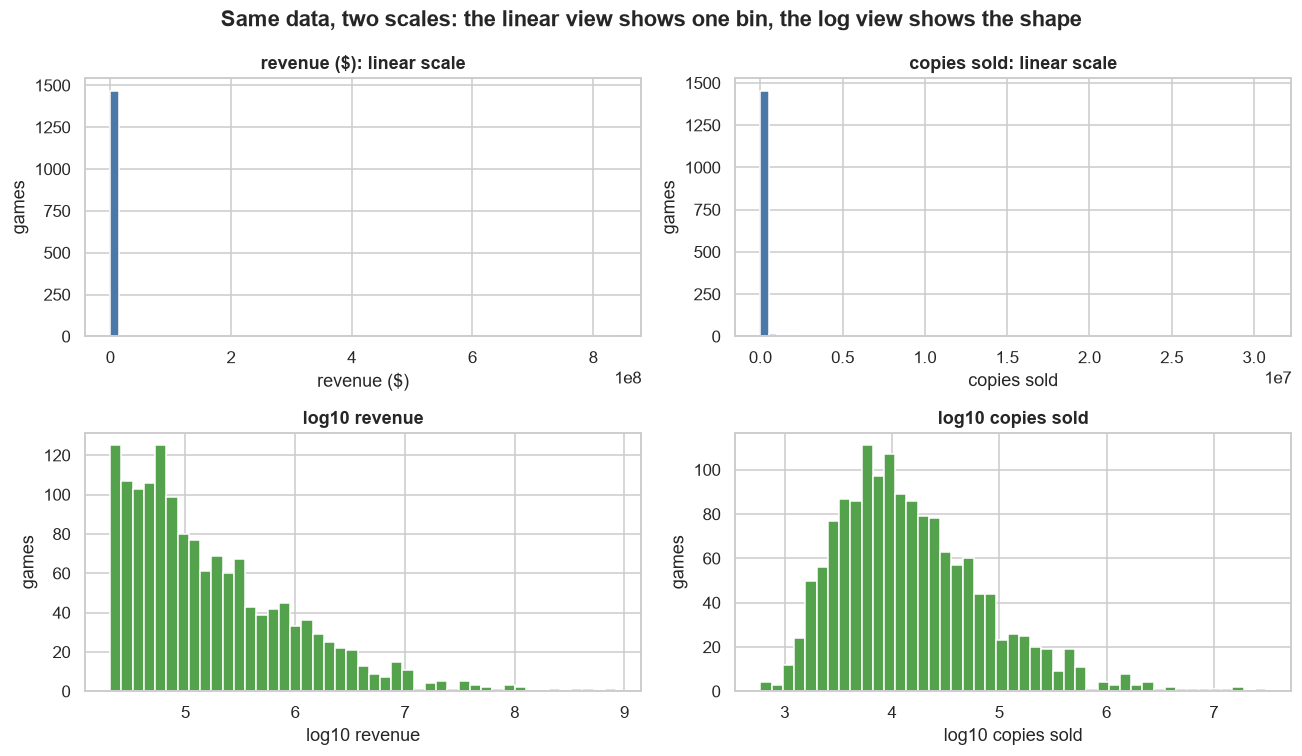

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
for ax, (col, lab) in zip(axes[0], [("revenue", "revenue ($)"), ("copiesSold", "copies sold")]):
    ax.hist(df[col], bins=60, color="#4C78A8"); ax.set_title(f"{lab}: linear scale"); ax.set_xlabel(lab); ax.set_ylabel("games")
for ax, (col, lab) in zip(axes[1], [("log_revenue", "log10 revenue"), ("log_copies", "log10 copies sold")]):
    ax.hist(df[col], bins=45, color="#54A24B"); ax.set_title(f"{lab}"); ax.set_xlabel(lab); ax.set_ylabel("games")
fig.suptitle("Same data, two scales: the linear view shows one bin, the log view shows the shape", fontweight="bold")
fig.tight_layout()
rs.save_fig(fig, "r01_scale_comparison.png"); plt.show()

**Reading the table.** Log10 brings revenue skew from ≈ 23 to ≈ 1.2 and copies sold from ≈ 19 to ≈ 1.0. The residual right skew of log-revenue is what left-truncation produces: the sample contains only the upper part of the revenue distribution (notebook 05 tests this directly). Rank-based and resampling methods therefore remain the primary tools.

## 5. Save the analysis-ready dataset

In [ ]:
keep = ["name", "releaseDate", "release_month", "publisherClass", "copiesSold", "price", "revenue", "avgPlaytime",
        "reviewScore", "reviewScore_clean", "has_review", "is_free", "log_revenue", "log_copies", "log_price",
        "log_playtime", "revenue_per_copy", "steamId"]
# Single processed file: overwrite the base cleaned_data.csv (written by the cleaning
# section above) with the enriched version. Any column already in cleaned_data.csv that
# is not in `keep` is carried along, so nothing from the base file is lost.
cleaned_path = rs.PROCESSED_DIR / "cleaned_data.csv"
base_cols = pd.read_csv(cleaned_path, nrows=0).columns
extra = [c for c in base_cols if c not in keep]
out = df[keep + extra]
out.to_csv(cleaned_path, index=False)
print(f"Saved data/processed/cleaned_data.csv  ->  {out.shape}")

# robust_data.csv is retired: its columns now live in cleaned_data.csv
(rs.PROCESSED_DIR / "robust_data.csv").unlink(missing_ok=True)

decisions = pd.DataFrame([
    ["reviewScore == 0", "-> NaN in reviewScore_clean; has_review flag kept", "Not missing at random (higher revenue)"],
    ["price == 0", "is_free flag; log_price defined for paid games only", "Different business model; log(0) undefined"],
    ["avgPlaytime == 0", "-> NaN in log_playtime", "log(0) undefined (1 row)"],
    ["Hobbyist (n=1)", "already merged into Indie in Week 1", "Group too small to estimate"],
    ["revenue, copiesSold", "log10 versions added", "Skew 23 / 19 -> ~1"],
    ["Selection on revenue", "carried as a caveat; truncated likelihood in notebook 05", "Top-1,500 sample"],
], columns=["issue", "decision", "reason"])
rs.save_table(decisions, "robust_data_decisions.csv")
decisions